# Fabric CU Analyzer  v2.0
Marco Pozzan

Comprehensive **CU, Throttling, Peak, Carry-Forward, and Sizing** analysis for Microsoft Fabric
Native authentication via `notebookutils` — no external dependencies.

---

| Stadio | Finestra | Trigger | Effetto |
|---|---|---|---|
| 0 – Overage protection | < 10 min | > 0% future capacity | No effect |
| 1 – Interactive DELAY  | 10 min | window 10min > 100% | +20s on interactive query |
| 2 – Interactive REJECTION | 60 min | window 60min > 100% | Report / rejected queries |
| 3 – Background REJECTION  | 24 hours | window 24h > 100% | All job rejected |

**Formula recovery:** `min_recovery = ((pct - 100) / 100) × window_duration`

## Step 1 — Configuration

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CONFIGURATION  --  edit only this cell
# ═══════════════════════════════════════════════════════════════════════

# ── Azure ──────────────────────────────────────────────────────────────
SUBSCRIPTION_ID  = ""  # <-- your subscription
CAPACITY_NAME    = "regolofabric"   # nome capacity (es. 'fabric-prod') — Leave blank for auto-detect

# ── Analysis period ─────────────────────────────────────────────────────
DAYS_BACK        = 7    # days of history
GRANULARITY_MIN  = 30   # metric granularity in minutes (30 or 60 recommended)
TOP_PEAKS        = 10   # number of top peaks to display


# ── Service Principal credentials ───────────────────────────────────────
# Option A: Key Vault (recommended for production)
#   Set USE_KEYVAULT=True and enter the Key Vault name
#   Secrets must be named: fabric-tenant-id, fabric-client-id, fabric-client-secret
USE_KEYVAULT     = False
KEYVAULT_NAME    = ""   # es. 'kv-regolofarm'

# Option B: direct input (development/test only)
TENANT_ID        = ""   # Leave blank if you use Key Vault
CLIENT_ID        = ""   # Leave blank if you use Key Vault
CLIENT_SECRET    = ""   # Leave blank if you use Key Vault

# ── Export (optional) ───────────────────────────────────────────────────
# Lakehouse path to save CSV and JSON (leave empty to disable)
# e.g. 'Files/cu_analyzer/' or '' to disable
EXPORT_PATH      = "Files/cu_analyzer/"

print("Configuration loaded")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 12, Finished, Available, Finished, False)

Configuration loaded


## Step 2 - Authentication e import

In [11]:
import json, warnings
from datetime import datetime, timedelta, timezone
import requests
import pandas as pd
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

# ── Brand colors ────────────────────────────────────────────
NAVY   = "#1B3A6B"
ORANGE = "#C55A11"
SKY    = "#BDD7EE"

ARM_BASE    = "https://management.azure.com"
FABRIC_BASE = "https://api.fabric.microsoft.com/v1"
MONITOR_API = "2024-02-01"
RG_URL      = f"{ARM_BASE}/providers/Microsoft.ResourceGraph/resources?api-version=2021-03-01"
METRICS     = ["CUPercent","CUKiloSecondsConsumed","ActiveCUSeconds","ThrottlingPercentage"]
SKU_CU      = {"F2":2,"F4":4,"F8":8,"F16":16,"F32":32,"F64":64,
               "F128":128,"F256":256,"F512":512,"F1024":1024,"F2048":2048}

# MS best practice thresholds
BP_AVG_OK=60;  BP_AVG_WARN=80
BP_P95_OK=70;  BP_P95_WARN=85
BP_PEAK_OK=80; BP_PEAK_WARN=100

# ── Retrieve credentials ────────────────────────────────────────────────
if USE_KEYVAULT and KEYVAULT_NAME:
    print(f"Retrieving credentials from Key Vault '{KEYVAULT_NAME}'...")
    TENANT_ID     = notebookutils.credentials.getSecret(KEYVAULT_NAME, "fabric-tenant-id")
    CLIENT_ID     = notebookutils.credentials.getSecret(KEYVAULT_NAME, "fabric-client-id")
    CLIENT_SECRET = notebookutils.credentials.getSecret(KEYVAULT_NAME, "fabric-client-secret")
    print("Credentials retrieved from Key Vault")
elif TENANT_ID and CLIENT_ID and CLIENT_SECRET:
    print("Credentials loaded from direct configuration")
else:
    raise ValueError("Missing credentials. Set USE_KEYVAULT=True or fill in TENANT_ID/CLIENT_ID/CLIENT_SECRET.")

# ── OAuth2 client_credentials token function ───────────────────────────
def get_token(scope: str) -> str:
    url = f"https://login.microsoftonline.com/{TENANT_ID}/oauth2/v2.0/token"
    data = {
        "grant_type":    "client_credentials",
        "client_id":     CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "scope":         scope,
    }
    r = requests.post(url, data=data)
    r.raise_for_status()
    return r.json()["access_token"]

# Acquire tokens
print("Acquiring Azure token...")
ARM_TOKEN    = get_token("https://management.azure.com/.default")
try:
    FABRIC_TOKEN = get_token("https://api.fabric.microsoft.com/.default")
    print("ARM + Fabric tokens acquired")
except:
    FABRIC_TOKEN = None
    print("ARM token acquired (Fabric API unavailable)")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 13, Finished, Available, Finished, False)

Credentials loaded from direct configuration
Acquiring Azure token...
ARM + Fabric tokens acquired


## Step 3 — Discovery Fabric Capacities

In [12]:
# ── Discovery via direct ARM (no Resource Graph) ────────────────────────
def list_capacities_arm(arm_tok, sub):
    url = (f"https://management.azure.com/subscriptions/{sub}"
           f"/providers/Microsoft.Fabric/capacities"
           f"?api-version=2023-11-01")
    r = requests.get(url, headers={"Authorization": f"Bearer {arm_tok}"})
    r.raise_for_status()
    caps = []
    for c in r.json().get("value", []):
        caps.append({
            "id":            c["id"],
            "name":          c["name"],
            "location":      c.get("location", ""),
            "sku":           c.get("sku", {}).get("name", "?"),
            "state":         c.get("properties", {}).get("state", "?"),
            "resourceGroup": c["id"].split("/resourceGroups/")[1].split("/")[0],
        })
    return caps

caps = list_capacities_arm(ARM_TOKEN, SUBSCRIPTION_ID)

if not caps:
    raise ValueError("No Fabric Capacity found.")

if CAPACITY_NAME:
    CAP = next((c for c in caps if c["name"].lower() == CAPACITY_NAME.lower()), None)
    if not CAP:
        raise ValueError(f"Capacity '{CAPACITY_NAME}' Not found. Available: {[c['name'] for c in caps]}")
elif len(caps) == 1:
    CAP = caps[0]
    print(f"Auto-selected: {CAP['name']}")
else:
    CAP = caps[0]
    print(f"Multiple capacities found -- using: {CAP['name']}. Set CAPACITY_NAME to select another.")

CAP_NAME = CAP["name"]
CAP_ID   = CAP["id"]
SKU      = str(CAP.get("sku", "?"))
CU_TOT   = SKU_CU.get(SKU.upper(), 0)

rows_html = "".join(
    f"<tr><td><b>{c['name']}</b></td><td>{c.get('sku','?')}</td>"
    f"<td>{SKU_CU.get(str(c.get('sku','')).upper(),'?')}</td>"
    f"<td style='color:{'green' if c.get('state')=='Active' else 'orange'}'>{c.get('state','?')}</td>"
    f"<td>{c.get('location','')}</td><td>{c.get('resourceGroup','')}</td></tr>"
    for c in caps
)
display(HTML(f"""
<h3 style='color:{ORANGE}'>Fabric Capacities</h3>
<table border='1' cellpadding='6' cellspacing='0' style='border-collapse:collapse;font-family:monospace'>
<tr style='background:{NAVY};color:white'>
  <th>Nome</th><th>SKU</th><th>CU</th><th>Stato</th><th>Region</th><th>RG</th>
</tr>{rows_html}</table>
<br><b style='color:{ORANGE}'>Capacity analizzata:</b> {CAP_NAME} | SKU: {SKU} | {CU_TOT} CU
"""))
print(f"CAP_ID: {CAP_ID}")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 14, Finished, Available, Finished, False)

Nome,SKU,CU,Stato,Region,RG
regolofabric,F4,4,Active,West Europe,ufficio


CAP_ID: /subscriptions/262128aa-2a34-4494-884b-2ba7b4db14d7/resourceGroups/ufficio/providers/Microsoft.Fabric/capacities/regolofabric


## Step 4 — Download metrics

In [13]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 4 -- CU metrics via Metrics App DAX (final working version)
# ══════════════════════════════════════════════════════════════════════
# ── Auto-discover Metrics App dataset ────────────────────────────────
PBI_TOKEN = get_token("https://analysis.windows.net/powerbi/api/.default")
PBI_HDRS  = {"Authorization": f"Bearer {PBI_TOKEN}", "Content-Type": "application/json"}

DATASET_ID = None

# Search in all accessible workspaces
r_ws = requests.get("https://api.powerbi.com/v1.0/myorg/groups", headers=PBI_HDRS)
if r_ws.status_code == 200:
    for ws in r_ws.json().get("value", []):
        r_ds = requests.get(
            f"https://api.powerbi.com/v1.0/myorg/groups/{ws['id']}/datasets",
            headers=PBI_HDRS
        )
        if r_ds.status_code == 200:
            for ds in r_ds.json().get("value", []):
                name = ds.get("name", "")
                if "fabric capacity metrics" in name.lower():
                    DATASET_ID = ds["id"]
                    print(f"Dataset found: '{name}'")
                    print(f"  Workspace: '{ws['name']}'")
                    print(f"  ID: {DATASET_ID}")
                    break
        if DATASET_ID:
            break

if not DATASET_ID:
    raise ValueError(
        "Metrics App dataset not found. "
        "Make sure the app is installed and the Service Principal "
        "has Viewer access on the workspace."
    )

END_DT     = datetime.now(timezone.utc)
START_DT   = END_DT - timedelta(days=DAYS_BACK)
PERIOD     = f"last {DAYS_BACK} days"

PBI_TOKEN = get_token("https://analysis.windows.net/powerbi/api/.default")
PBI_HDRS  = {"Authorization": f"Bearer {PBI_TOKEN}", "Content-Type": "application/json"}

def dax(query):
    r = requests.post(
        f"https://api.powerbi.com/v1.0/myorg/datasets/{DATASET_ID}/executeQueries",
        headers=PBI_HDRS,
        json={"queries": [{"query": query}], "serializerSettings": {"includeNulls": True}}
    )
    if r.status_code == 200:
        return r.json()["results"][0]["tables"][0].get("rows", []), 200
    return [], r.status_code

# ── 1) CU Detail — all data, filter by date in pandas ────────────────
print("Querying CU Detail...")
rows_cu, sc = dax("""
EVALUATE
SUMMARIZECOLUMNS(
    'CU Detail'[Window start time],
    'CU Detail'[Base capacity units],
    "cu_s",    SUM('CU Detail'[CU (s)]),
    "int_s",   SUM('CU Detail'[Interactive]),
    "bg_s",    SUM('CU Detail'[Background]),
    "int_del", AVERAGE('CU Detail'[Interactive delay %]),
    "int_rej", AVERAGE('CU Detail'[Interactive rejection %]),
    "bg_rej",  AVERAGE('CU Detail'[Background rejection %])
)
""")
print(f"   status={sc}  rows={len(rows_cu)}")

# ── 2) Carry-forward overage ──────────────────────────────────────────
print("Querying Timepoint Overage Detail...")
rows_cf, sc2 = dax("""
EVALUATE
SUMMARIZECOLUMNS(
    'Timepoint Overage Detail'[Window start time],
    'Timepoint Overage Detail'[Base capacity units],
    "cf_add",   SUM('Timepoint Overage Detail'[Carry forward add]),
    "cf_burn",  SUM('Timepoint Overage Detail'[Carry forward burndown]),
    "cf_cumul", SUM('Timepoint Overage Detail'[Cumulative carry forward])
)
""")
print(f"   status={sc2}  rows={len(rows_cf)}")

# ── 3) Build DF ───────────────────────────────────────────────────────
DF    = pd.DataFrame()
DF_CF = pd.DataFrame()

if rows_cu:
    df_raw = pd.DataFrame(rows_cu)
    df_raw.columns = [
        c.replace("CU Detail[","").replace("[","").rstrip("]")
        for c in df_raw.columns
    ]
    df_raw["Window start time"] = pd.to_datetime(
        df_raw["Window start time"], utc=True, errors="coerce"
    )
    df_raw = df_raw.dropna(subset=["Window start time"])
    df_raw = df_raw.sort_values("Window start time")

    # Filter to requested period in pandas (no DAX date filter needed)
    df_raw = df_raw[
        (df_raw["Window start time"] >= START_DT) &
        (df_raw["Window start time"] <= END_DT)
    ]
    print(f"   After date filter: {len(df_raw)} rows")

    for col in ["cu_s","int_s","bg_s","int_del","int_rej","bg_rej","Base capacity units"]:
        if col in df_raw.columns:
            df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce").fillna(0)

    # CU% = CU(s) / (Base capacity units × 30s window)
    base_cu_s = (df_raw["Base capacity units"] * 30.0).replace(0, 1)
    df_raw["avg_pct"] = (df_raw["cu_s"] / base_cu_s * 100).round(2)

    # Resample from 30s to GRANULARITY_MIN
    df_raw = df_raw.set_index("Window start time").sort_index()
    df_res = df_raw.resample(f"{GRANULARITY_MIN}min").agg({
        "avg_pct": "mean",
        "cu_s":    "sum",
        "int_del": "max",
        "int_rej": "max",
        "bg_rej":  "max",
    }).reset_index()
    df_res.rename(columns={"Window start time": "ts"}, inplace=True)

    DF = pd.DataFrame({
        "ts":          df_res["ts"],
        "metric":      "CUPercent",
        "avg":         df_res["avg_pct"].round(2),
        "max":         df_res["avg_pct"].round(2),
        "total":       df_res["cu_s"],
        "int_del_pct": df_res.get("int_del", 0),
        "int_rej_pct": df_res.get("int_rej", 0),
        "bg_rej_pct":  df_res.get("bg_rej", 0),
    })

    print(f"   DF: {len(DF)} rows  |  CU% avg={DF['avg'].mean():.1f}%  max={DF['avg'].max():.1f}%")
    print(f"   Period: {DF['ts'].min()} -> {DF['ts'].max()}")

if rows_cf:
    DF_CF = pd.DataFrame(rows_cf)
    DF_CF.columns = [
        c.replace("Timepoint Overage Detail[","").replace("[","").rstrip("]")
        for c in DF_CF.columns
    ]
    DF_CF["Window start time"] = pd.to_datetime(
        DF_CF["Window start time"], utc=True, errors="coerce"
    )
    DF_CF.rename(columns={"Window start time": "ts"}, inplace=True)
    DF_CF = DF_CF[
        (DF_CF["ts"] >= START_DT) &
        (DF_CF["ts"] <= END_DT)
    ]
    for col in ["cf_add","cf_burn","cf_cumul","Base capacity units"]:
        if col in DF_CF.columns:
            DF_CF[col] = pd.to_numeric(DF_CF[col], errors="coerce").fillna(0)
    print(f"   DF_CF: {len(DF_CF)} rows")

# ── Fallback ──────────────────────────────────────────────────────────
if DF.empty:
    slots = pd.date_range(START_DT, END_DT, freq=f"{GRANULARITY_MIN}min", tz="UTC")
    DF = pd.DataFrame({
        "ts": slots, "metric": "CUPercent",
        "avg": 0.0, "max": 0.0, "total": 0.0,
    })
    print("Fallback empty DF")

print(f"\n{'='*55}")
print(f"CU rows:  {len(DF)}")
print(f"CF rows:  {len(DF_CF)}")
print(f"Period:   {START_DT.strftime('%Y-%m-%d')} -> {END_DT.strftime('%Y-%m-%d')}")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 15, Finished, Available, Finished, False)

Dataset found: 'Fabric Capacity Metrics'
  Workspace: 'Microsoft Fabric Capacity Metrics'
  ID: 191299e9-d36b-459a-9764-b3fcb10b32f8
Querying CU Detail...
   status=200  rows=37428
Querying Timepoint Overage Detail...
   status=200  rows=37428
   After date filter: 20159 rows
   DF: 337 rows  |  CU% avg=46.7%  max=71.8%
   Period: 2026-03-07 23:30:00+00:00 -> 2026-03-14 23:30:00+00:00
   DF_CF: 20159 rows

CU rows:  337
CF rows:  20159
Period:   2026-03-07 -> 2026-03-14


## Step 5 — KPI Summary

In [1]:
# Ensure DF is in the expected format for downstream cells
cu  = DF[DF["metric"]=="CUPercent"].copy()
thr = DF[DF["metric"]=="ThrottlingPercentage"].copy()
ks  = DF[DF["metric"]=="CUKiloSecondsConsumed"].copy()

avg_cu  = cu["avg"].mean()
med_cu  = cu["avg"].median()
p95_cu  = cu["avg"].quantile(.95)
p99_cu  = cu["avg"].quantile(.99)
max_cu  = cu["avg"].max()
std_cu  = cu["avg"].std()
cv_pct  = std_cu/avg_cu*100 if avg_cu>0 else 0
thr_avg = thr["avg"].mean() if not thr.empty else 0
thr_max = thr["max"].max()  if not thr.empty and thr["max"].notna().any() else 0
cu_s_total = float(DF["total"].sum()) if "total" in DF.columns else 0.0
cu_ks      = cu_s_total / 1000   # convert CU·s to CU·ks for display

def kpi_color(v, ok, warn):
    if v >= warn:  return "#c0392b"   # rosso
    if v >= ok:    return "#e67e22"   # arancio
    return "#27ae60"                  # verde

def kpi_card(title, value, subtitle, color):
    return f"""
    <div style='display:inline-block;min-width:150px;margin:6px;padding:14px 18px;
                border:2px solid {color};border-radius:8px;text-align:center;vertical-align:top'>
      <div style='font-size:11px;color:#666;font-weight:bold;text-transform:uppercase'>{title}</div>
      <div style='font-size:28px;font-weight:bold;color:{color};margin:6px 0'>{value}</div>
      <div style='font-size:11px;color:#888'>{subtitle}</div>
    </div>"""


cards = kpi_card("CU% Average",   f"{avg_cu:.1f}%", f"OK &lt; {BP_AVG_OK}%", kpi_color(avg_cu, BP_AVG_OK, BP_AVG_WARN))
cards += kpi_card("CU% P95",      f"{p95_cu:.1f}%", f"OK &lt; {BP_P95_OK}%", kpi_color(p95_cu, BP_P95_OK, BP_P95_WARN))
cards += kpi_card("CU% P99",      f"{p99_cu:.1f}%", "99th percentile", kpi_color(p99_cu, BP_P95_OK, BP_P95_WARN))
cards += kpi_card("Peak",         f"{max_cu:.1f}%", "absolute maximum", kpi_color(max_cu, BP_PEAK_OK, BP_PEAK_WARN))
cards += kpi_card("Throttling",   f"{thr_avg:.3f}%","period average", "#c0392b" if thr_avg>0 else "#27ae60")
cu_hours = cu_s_total / 3600 if cu_s_total > 0 else 0.0
cards += kpi_card("CU·ore", f"{cu_hours:.1f}", "CU·s totali / 3600", NAVY)
cards += kpi_card("CV Volatility",f"{cv_pct:.1f}%", "Coeff. Variation", kpi_color(cv_pct, 50, 80))

display(HTML(f"""
<div style='border-left:4px solid {ORANGE};padding-left:12px;margin-bottom:12px'>
  <h3 style='color:{NAVY};margin:0'>KPI Summary — {CAP_NAME} ({SKU} · {CU_TOT} CU)</h3>
  <span style='color:#888;font-size:12px'>{PERIOD}</span>
</div>
<div>{cards}</div>
"""))


StatementMeta(, , -1, SessionStarting, , SessionStarting, True)

## Step 6 — Throttling analysis (official Microsoft model)

In [15]:
cu_s = cu.set_index("ts")["avg"].dropna().sort_index()

# Detected granularity
gran_min = max(1, int((cu_s.index[1]-cu_s.index[0]).total_seconds()/60)) if len(cu_s)>1 else GRANULARITY_MIN

# Rolling windows approximating the 3 Microsoft throttling stages
w10  = max(1, round(10   / gran_min))
w60  = max(1, round(60   / gran_min))
w24h = max(1, round(1440 / gran_min))

r10  = cu_s.rolling(w10,  min_periods=1).mean()
r60  = cu_s.rolling(w60,  min_periods=1).mean()
r24h = cu_s.rolling(w24h, min_periods=1).mean()

# Occurrences per stage
n_delay = int((r10  > 100).sum())
n_irej  = int((r60  > 100).sum())
n_bgrej = int((r24h > 100).sum())

# Peak per stage
pk_delay = float(r10.max())
pk_irej  = float(r60.max())
pk_bgrej = float(r24h.max())

# MS recovery formula: ((pct-100)/100) x window_duration
def rec_min(pct, win): return max(0.0, ((pct-100)/100)*win) if pct>100 else 0.0
def fmt_min(m): return "—" if m<=0 else f"{m:.0f} min" if m<60 else f"{m/60:.1f} h"

def stage_badge(n, label, color):
    bg = color if n>0 else "#27ae60"
    txt = f"{n} intervalli" if n>0 else "OK"
    return f"<span style='background:{bg};color:white;padding:3px 10px;border-radius:12px;font-size:12px;font-weight:bold'>{label}: {txt}</span>"

badges = (
    stage_badge(n_delay, "DELAY",   "#e67e22") + "  " +
    stage_badge(n_irej,  "INT REJ", "#c0392b") + "  " +
    stage_badge(n_bgrej, "BG REJ",  "#8e44ad")
)

def stg_row(stadio, finestra, effetto, n, pk, rc, color):
    c = color if n>0 else "#27ae60"
    status = f"<b style='color:{c}'>{n} intervalli</b>" if n>0 else "<span style='color:#27ae60'> OK</span>"
    return (
        f"<tr>"
        f"<td><b style='color:{c}'>{stadio}</b></td>"
        f"<td style='text-align:center'>{finestra}</td>"
        f"<td>{effetto}</td>"
        f"<td style='text-align:center'>{status}</td>"
        f"<td style='text-align:center'><b style='color:{c}'>{pk:.1f}%</b></td>"
        f"<td style='text-align:center'>{fmt_min(rc)}</td>"
        f"</tr>"
    )

table_html = f"""
<table border='1' cellpadding='8' cellspacing='0' 
style='border-collapse:collapse;font-family:monospace;width:100%'>
<tr style='background:{NAVY};color:white'> 
<th>Stadium</th><th>Window</th><th>Effect</th> 
<th>Occurrences</th><th>Peak %</th><th>Estimated recovery</th>
</tr>
<tr style='background:#f9f9f9'> 
<td><b>0 – Overage protection</b></td><td style='text-align:center'>&lt; 10 min</td> 
<td>No user effects</td><td colspan='3' style='text-align:center;color:#888'>N/A</td>
</tr>
{stg_row('1 – Interactive DELAY','10 min','+20s on interactive queries',n_delay,pk_delay,rec_min(pk_delay,10),'#e67e22')}
{stg_row('2 – Interactive REJECTION','60 min','User reports / queries rejected',n_irej,pk_irej,rec_min(pk_irej,60),'#c0392b')}
{stg_row('3 – Background REJECTION','24 hours','ALL jobs rejected (refresh, Spark, pipeline)',n_bgrej,pk_bgrej,rec_min(pk_bgrej,1440),'#8e44ad')}
</table>
"""

# Carry-forward
over = cu_s[cu_s>100]-100
n_ov   = len(over)
avg_ov = float(over.mean()) if n_ov else 0.0
max_ov = float(over.max())  if n_ov else 0.0

cf_color = "#c0392b" if n_ov>10 else "#e67e22" if n_ov>0 else "#27ae60"
cf_html = f"""

<div style='margin-top:16px;padding:12px;border-left:4px solid {cf_color};background:#fafafa'> 
<b>Carry-Forward (accumulated CU debt)</b><br> 
Intervals with overage (&gt;100%): <b style='color:{cf_color}'>{n_ov}</b> &nbsp;| 
Average Overage: <b>{avg_ov:.1f}%</b> &nbsp;| 
Peak overage: <b>{max_ov:.1f}%</b>
</div>
"""

# Consecutive throttling event log
events, in_ev, ev_start, ev_vals = [], False, None, []
for ts_v, v in r10.items():
    if v>100 and not in_ev:  in_ev=True; ev_start=ts_v; ev_vals=[v]
    elif v>100 and in_ev:    ev_vals.append(v)
    elif v<=100 and in_ev:
        in_ev=False
        events.append({"Inizio":str(ev_start)[:19],"Fine":str(ts_v)[:19],
                       "Durata (min)":len(ev_vals)*gran_min,"Picco %":round(float(max(ev_vals)),1)})
        ev_vals=[]
if in_ev and ev_vals:
    events.append({"Inizio":str(ev_start)[:19],"Fine":"in corso",
                   "Durata (min)":len(ev_vals)*gran_min,"Picco %":round(float(max(ev_vals)),1)})

ev_html = ""
if events:
    df_ev = pd.DataFrame(events)
    ev_html = f"<br><b>Log eventi throttling ({len(events)} episodi):</b>"
    ev_html += df_ev.to_html(index=False, border=0,
                              classes="", justify="center")

# ThrottlingPercentage metric
thr_metric_html = ""
if not thr.empty:
    n_thr_pos = int((thr["avg"]>0).sum())
    c = "#c0392b" if n_thr_pos>0 else "#27ae60"
    thr_metric_html = f"""
    <div style='margin-top:12px;padding:8px;border-left:4px solid {c};background:#fafafa'>
      <b>Metrica ThrottlingPercentage:</b>
      avg={thr_avg:.4f}%  |  max={thr_max:.2f}%  |
      intervalli &gt; 0: <b style='color:{c}'>{n_thr_pos}</b>
    </div>"""

display(HTML(f"""
<div style='border-left:4px solid {ORANGE};padding-left:12px;margin-bottom:12px'>
  <h3 style='color:{NAVY};margin:0'>Analyze Throttling</h3>
</div>
<div style='margin-bottom:10px'>{badges}</div>
{table_html}
{cf_html}
{thr_metric_html}
{ev_html}
"""))

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 17, Finished, Available, Finished, False)

## Step 7 — Peak & Percentile Analysis

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 18, Finished, Available, Finished, False)

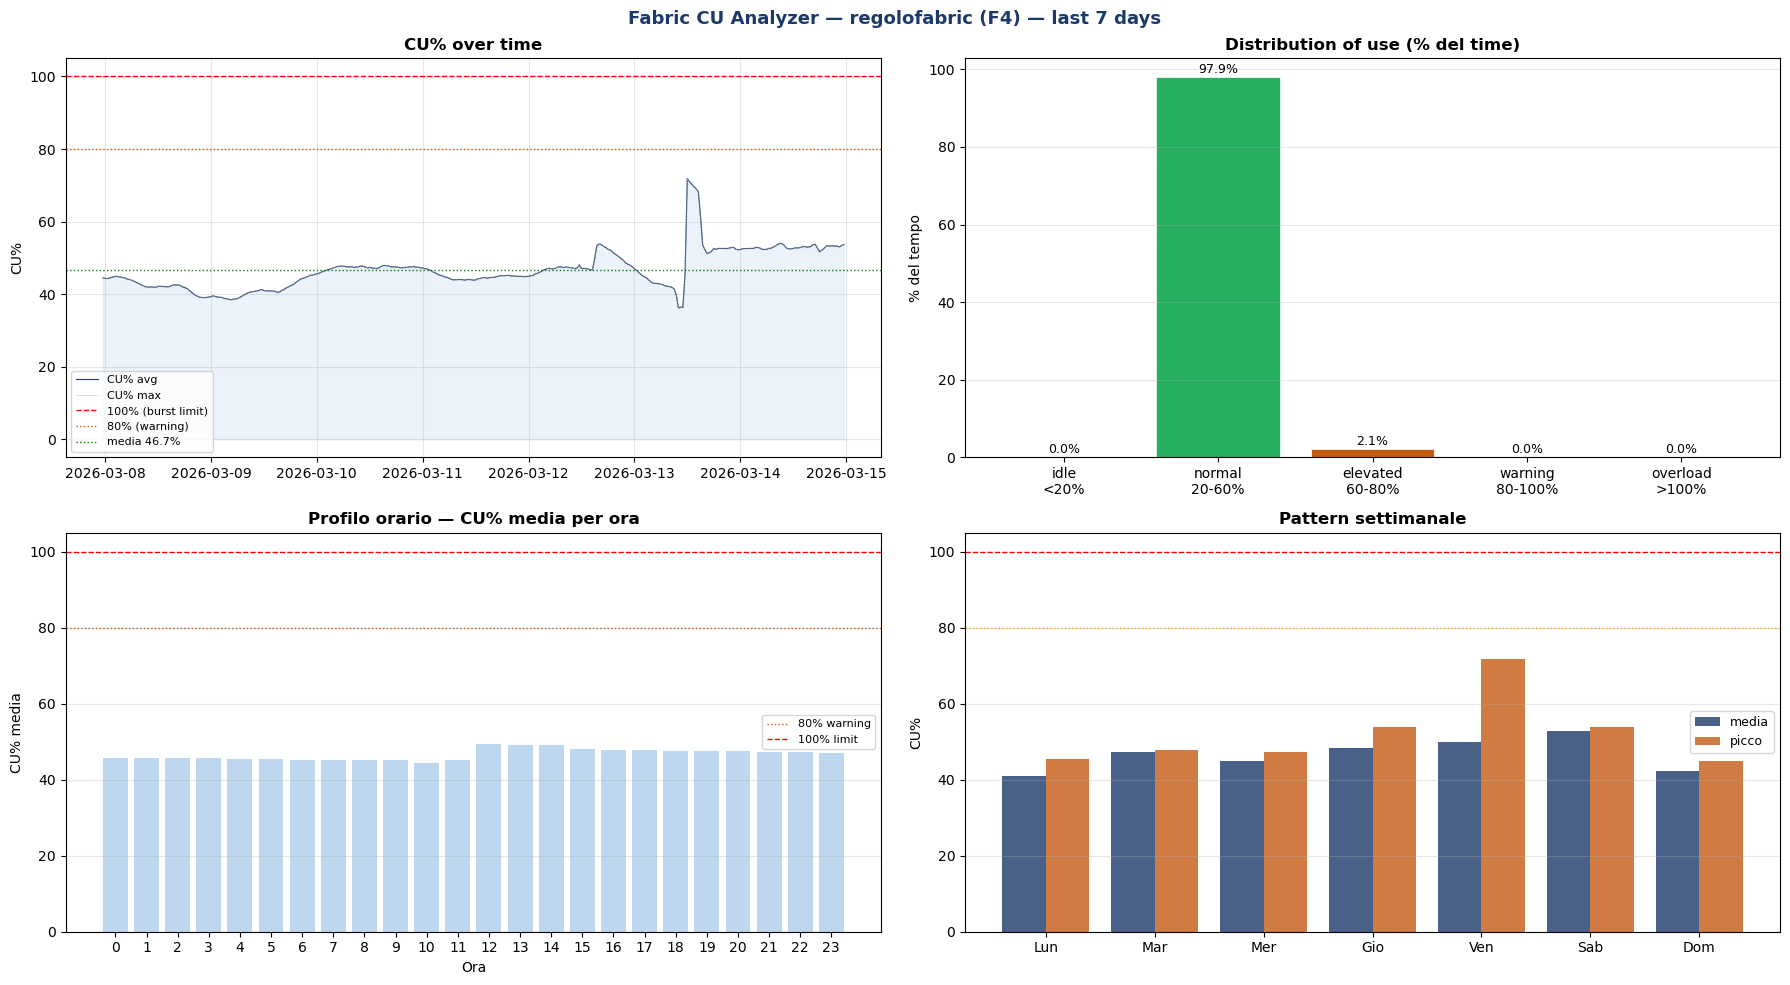


Charts rendered


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cu["ts"] = pd.to_datetime(cu["ts"])
cu["hour"]    = cu["ts"].dt.hour
cu["weekday"] = cu["ts"].dt.day_name()

p50=cu["avg"].quantile(.50); p75=cu["avg"].quantile(.75)
p90=cu["avg"].quantile(.90)

# ── Percentile table ────────────────────────────────────────────────────
def pct_row(lbl, val, ok_thr, warn_thr, soglia_label):
    c = "#c0392b" if val>=warn_thr else "#e67e22" if val>=ok_thr else "#27ae60"
    status = "CRIT" if val>=warn_thr else "WARN" if val>=ok_thr else "OK"
    return (f"<tr><td><b>{lbl}</b></td>"
            f"<td style='text-align:right'><b style='color:{c}'>{val:.1f}%</b></td>"
            f"<td style='color:#888;font-size:12px'>{soglia_label}</td>"
            f"<td>{status}</td></tr>")

perc_table = f"""
<table border='1' cellpadding='7' cellspacing='0'
       style='border-collapse:collapse;font-family:monospace'>
<tr style='background:{NAVY};color:white'>
  <th>Statistics</th><th>CU%</th><th>Soglia MS</th><th>Status</th>
</tr>
{pct_row('Average',    avg_cu, BP_AVG_OK, BP_AVG_WARN, f'OK &lt; {BP_AVG_OK}%')}
{pct_row('Median',  med_cu, BP_AVG_OK, BP_AVG_WARN, '—')}
{pct_row('P75',      p75,    65, 80, '—')}
{pct_row('P90',      p90,    70, 85, '—')}
{pct_row('P95',      p95_cu, BP_P95_OK, BP_P95_WARN, f'OK &lt; {BP_P95_OK}%')}
{pct_row('P99',      p99_cu, BP_P95_OK, BP_P95_WARN, '—')}
{pct_row('Picco',    max_cu, BP_PEAK_OK, BP_PEAK_WARN, f'OK &lt; {BP_PEAK_OK}%')}
<tr><td><b>Std Dev</b></td><td style='text-align:right'>{std_cu:.1f}%</td><td colspan='2' style='color:#888'>—</td></tr>
<tr><td><b>CV (volatilità)</b></td><td style='text-align:right'>{cv_pct:.1f}%</td>
    <td style='color:#888'>OK &lt; 50%</td>
    <td>{'WARN' if cv_pct>=50 else 'OK'}</td></tr>
</table>
"""
display(HTML(f"<h3 style='color:{ORANGE}'>Statistiche CU%</h3>{perc_table}"))

# ── Matplotlib charts ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(f"Fabric CU Analyzer — {CAP_NAME} ({SKU}) — {PERIOD}",
             fontsize=13, fontweight="bold", color=NAVY)

# 1) CU% time series
ax1 = axes[0,0]
ax1.fill_between(cu["ts"], cu["avg"], alpha=0.3, color=SKY)
ax1.plot(cu["ts"], cu["avg"], color=NAVY, linewidth=0.8, label="CU% avg")
if cu["max"].notna().any():
    ax1.plot(cu["ts"], cu["max"], color="#aaa", linewidth=0.4, linestyle="--", label="CU% max")
ax1.axhline(100,  color="red",    linestyle="--", linewidth=1, label="100% (burst limit)")
ax1.axhline(80,   color=ORANGE,   linestyle=":",  linewidth=1, label="80% (warning)")
ax1.axhline(avg_cu, color="green",linestyle=":",  linewidth=1, label=f"media {avg_cu:.1f}%")
ax1.set_title("CU% over time", fontweight="bold")
ax1.set_ylabel("CU%"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2) Bucket distribution
ax2 = axes[0,1]
n = len(cu)
buckets = {
    "idle\n<20%":    (cu["avg"]<20).sum()/n*100,
    "normal\n20-60%":((cu["avg"]>=20)&(cu["avg"]<60)).sum()/n*100,
    "elevated\n60-80%":((cu["avg"]>=60)&(cu["avg"]<80)).sum()/n*100,
    "warning\n80-100%":((cu["avg"]>=80)&(cu["avg"]<100)).sum()/n*100,
    "overload\n>100%":(cu["avg"]>=100).sum()/n*100,
}
colors_b=[SKY,"#27ae60",ORANGE,"#e67e22","#c0392b"]
bars=ax2.bar(buckets.keys(), buckets.values(), color=colors_b, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, buckets.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax2.set_title("Distribution of use (% del time)", fontweight="bold")
ax2.set_ylabel("% del tempo"); ax2.grid(axis="y", alpha=0.3)

# 3) Hourly heatmap
ax3 = axes[1,0]
hourly = cu.groupby("hour")["avg"].mean()
ax3.bar(hourly.index, hourly.values,
        color=["#c0392b" if v>=100 else "#e67e22" if v>=80 else NAVY if v>=60 else SKY
               for v in hourly.values])
ax3.axhline(80,  color=ORANGE, linestyle=":", linewidth=1, label="80% warning")
ax3.axhline(100, color="red",  linestyle="--",linewidth=1, label="100% limit")
ax3.set_title("Profilo orario — CU% media per ora", fontweight="bold")
ax3.set_xlabel("Ora"); ax3.set_ylabel("CU% media")
ax3.set_xticks(range(0,24)); ax3.legend(fontsize=8); ax3.grid(axis="y",alpha=0.3)

# 4) Weekly pattern
ax4 = axes[1,1]
DAYS=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
DAYS_IT=["Lun","Mar","Mer","Gio","Ven","Sab","Dom"]
weekly_mean = cu.groupby("weekday")["avg"].mean().reindex(DAYS)
weekly_max  = cu.groupby("weekday")["avg"].max().reindex(DAYS)
x = np.arange(len(DAYS))
ax4.bar(x-0.2, weekly_mean.fillna(0).values, 0.4, label="media", color=NAVY, alpha=0.8)
ax4.bar(x+0.2, weekly_max.fillna(0).values,  0.4, label="picco", color=ORANGE, alpha=0.8)
ax4.axhline(80,  color="orange",linestyle=":", linewidth=1)
ax4.axhline(100, color="red",   linestyle="--",linewidth=1)
ax4.set_title("Pattern settimanale", fontweight="bold")
ax4.set_xticks(x); ax4.set_xticklabels(DAYS_IT)
ax4.set_ylabel("CU%"); ax4.legend(fontsize=9); ax4.grid(axis="y",alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/cu_charts.png", dpi=140, bbox_inches="tight")
plt.show()
print("\nCharts rendered")

## Step 8 — Top peaks & Throttling time series

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 19, Finished, Available, Finished, False)

,Timestamp,CU% avg,CU% max
1,2026-03-13 12:00:00,71.85,71.85
2,2026-03-13 12:30:00,70.96,70.96
3,2026-03-13 13:00:00,70.32,70.32
4,2026-03-13 13:30:00,69.62,69.62
5,2026-03-13 14:00:00,69.04,69.04
6,2026-03-13 14:30:00,68.29,68.29
7,2026-03-13 15:00:00,61.44,61.44
8,2026-03-14 09:00:00,53.98,53.98
9,2026-03-14 09:30:00,53.94,53.94
10,2026-03-12 16:00:00,53.83,53.83


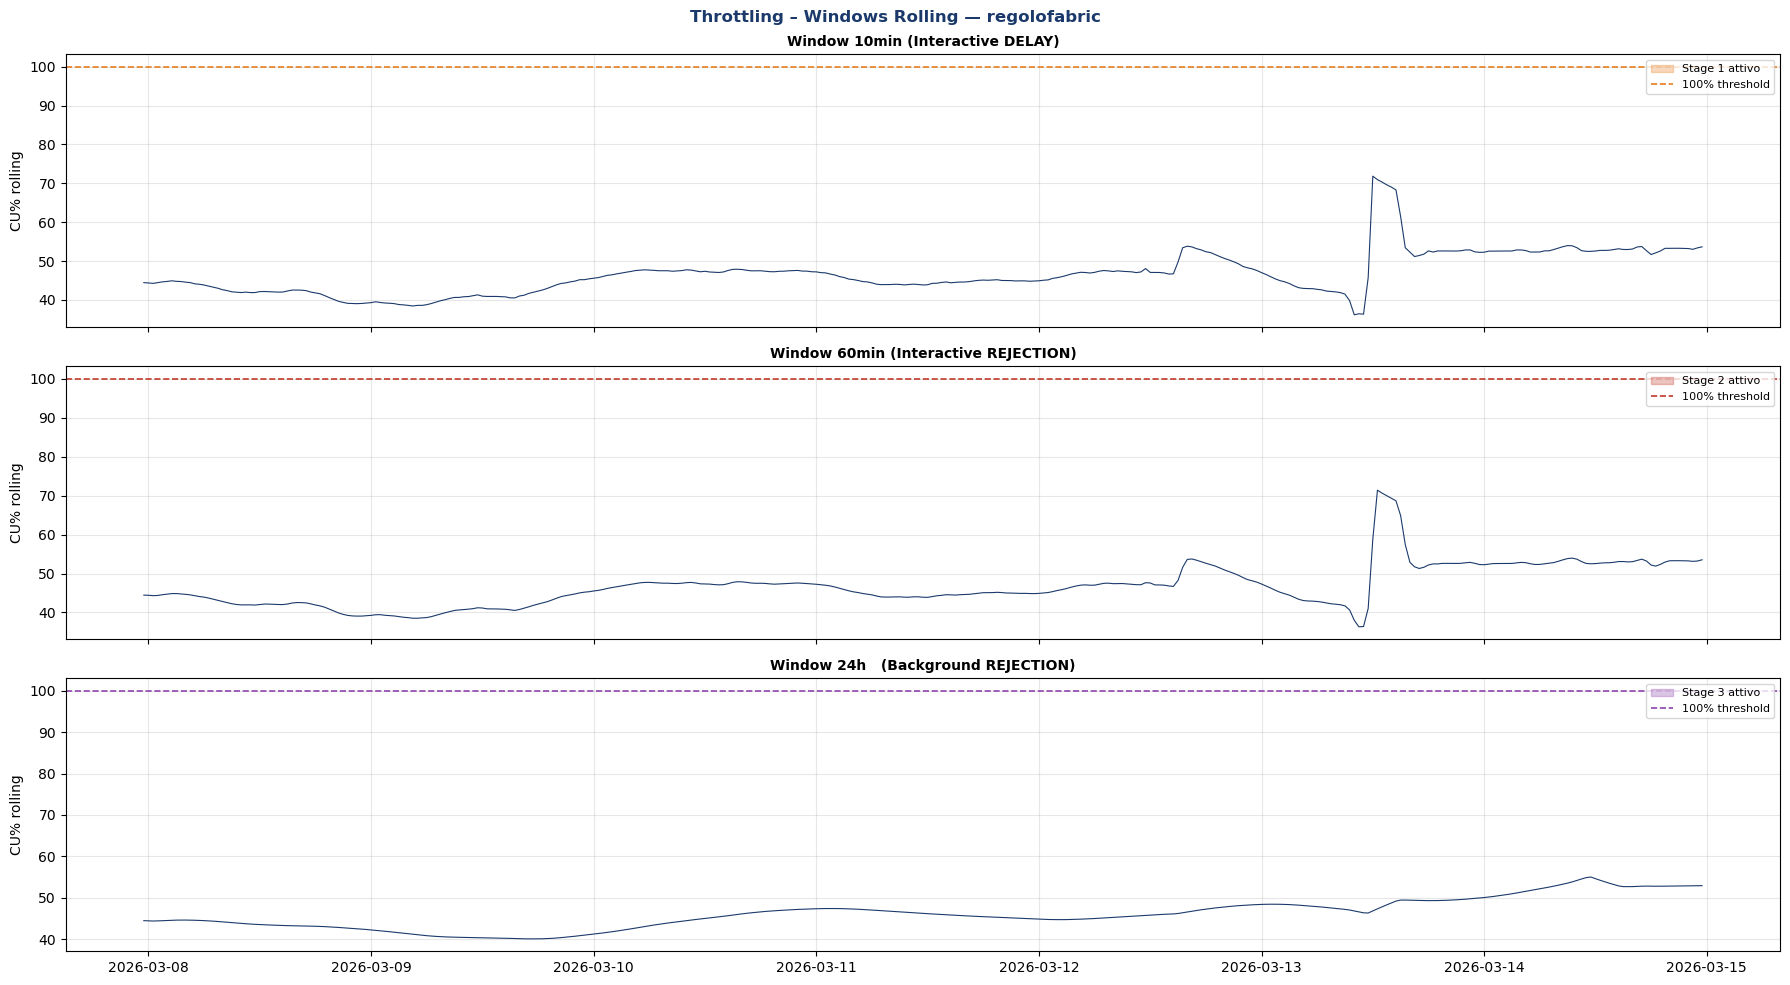

In [17]:
import matplotlib.pyplot as plt

# ── Top N peaks ─────────────────────────────────────────────────────────
top_peaks = cu.nlargest(TOP_PEAKS, "avg")[["ts","avg","max"]].copy()
top_peaks["ts"] = top_peaks["ts"].astype(str).str[:19]
top_peaks.columns = ["Timestamp","CU% avg","CU% max"]
top_peaks = top_peaks.round(2).reset_index(drop=True)
top_peaks.index += 1

display(HTML(f"<h3 style='color:{ORANGE}'>Top {TOP_PEAKS} absolute peaks</h3>"))
display(top_peaks)

# ── Throttling time series chart ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
fig.suptitle(f"Throttling – Windows Rolling — {CAP_NAME}",
             fontsize=12, fontweight="bold", color=NAVY)

ts_idx = r10.index

for ax, data, label, color, thr_label in [
    (axes[0], r10,  "Window 10min (Interactive DELAY)",       "#e67e22", "Stage 1"),
    (axes[1], r60,  "Window 60min (Interactive REJECTION)",   "#c0392b", "Stage 2"),
    (axes[2], r24h, "Window 24h   (Background REJECTION)",    "#8e44ad", "Stage 3"),
]:
    ax.fill_between(ts_idx, data, where=(data>100), alpha=0.3, color=color, label=f"{thr_label} attivo")
    ax.plot(ts_idx, data, color=NAVY, linewidth=0.8)
    ax.axhline(100, color=color, linestyle="--", linewidth=1.2, label="100% threshold")
    ax.set_ylabel("CU% rolling")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/throttling_chart.png", dpi=140, bbox_inches="tight")
plt.show()

## Step 9 — Recommended sizing

In [18]:
def best_sku(cu_needed):
    for nm, cu_v in sorted(SKU_CU.items(), key=lambda x: x[1]):
        if cu_v >= cu_needed: return f"{nm} ({cu_v} CU)"
    return "F2048+ (custom)"

if CU_TOT > 0:
    avg_cu_abs = avg_cu / 100 * CU_TOT
    p95_cu_abs = p95_cu / 100 * CU_TOT
    rec_lo = p95_cu_abs * 1.25
    rec_hi = p95_cu_abs * 1.50

    is_undersized = p95_cu > 80
    is_oversized  = avg_cu_abs < CU_TOT * 0.30

    if is_undersized: 
        verdict_color = "#c0392b" 
        verdict = "UNDERDIMENSIONED — upgrade recommended" 
    elif is_oversized: 
        verdict_color = "#27ae60" 
        verdict = "Probably oversized — rate downgrade" 
    else: 
        verdict_color = "#27ae60" 
        verdict = "Sizing appropriate for the current load"

    display(HTML(f""" 
    <div style='border-left:4px solid {ORANGE};padding-left:12px;margin-bottom:12px'> 
    <h3 style='color:{NAVY};margin:0'>Sizing & SKU Recommendation</h3> 
    <span style='color:#888;font-size:12px'>Based on P95 + buffer 25-50% (MS Capacity Planning Guide)</span> 
    </div> 
    <table border='1' cellpadding='8' cellspacing='0' 
    style='border-collapse:collapse;font-family:monospace'> 
    <tr style='background:{NAVY};color:white'><th>Item</th><th>Value</th></tr> 
    <tr><td>SKU current</td><td><b>{SKU}</b> ({CU_TOT} CU)</td></tr> 
    <tr><td>CUs used (average)</td><td>{avg_cu_abs:.1f} CUs &nbsp;({avg_cu:.1f}%)</td></tr> 
    <tr><td>Used CUs (P95)</td><td>{p95_cu_abs:.1f} CU &nbsp;({p95_cu:.1f}%)</td></tr> 
    <tr><td>Recommended +25% (MS)</td><td><b>{best_sku(rec_lo)}</b> &nbsp;(P95 {p95_cu_abs:.0f} × 1.25 = {rec_lo:.0f} CU)</td></tr> 
    <tr><td>Recommended +50% (MS)</td><td><b>{best_sku(rec_hi)}</b> &nbsp;(P95 {p95_cu_abs:.0f} × 1.50 = {rec_hi:.0f} CU)</td></tr> 
    <tr><td colspan='2' style='text-align:center;font-size:14px;color:{verdict_color}'><b>{verdict}</b></td></tr> 
    </table> 
    """))
else:
    print("Unknown SKU -- sizing calculation unavailable")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 20, Finished, Available, Finished, False)

## Step 10 — Actionable Recommendations

In [19]:

recs = []
def rec(sev, cat, msg): recs.append((sev, cat, msg))

# Throttling
if n_bgrej:  rec("crit", "Throttling BG Rejection", 
                f"{n_bgrej} Background Rejection intervals. ALL jobs rejected." 
                "Immediate action: pause+resume capacity (instant reset overage) or upgrade SKU.")
if n_irej:   rec("crit", "Throttling Int. Rejection", 
                f"{n_irej} Interactive Rejection ranges. Power BI reports and user queries rejected." 
                "Enable Surge Protection or scale SKU.")
if n_delay and not n_irej: 
                rec("warn", "Throttling Int. Delay", 
                    f"{n_delay} intervals with +20s delay on interactive queries." 
                    f"Recovery Estimated: {fmt_min(rec_min(pk_delay,10))}. Monitor trend.")
if not n_bgrej and not n_irej and not n_delay:
                rec("ok", "Throttling", "No throttling in the analyzed period.")

# Carry-forward
if n_ov>10: rec("warn", "Carry-Forward",
                f"{n_ov} intervals >100%. Accumulated CU debt increases progressive throttling risk. "
                "Distribute heavy jobs across different time slots or enable Surge Protection.")
elif n_ov>0: rec("ok", "Carry-Forward", f"Limited carry-forward ({n_ov} intervals). Monitor.")
else:        rec("ok", "Carry-Forward", "No carry-forward in the period.")

# Average utilization
if avg_cu>=BP_AVG_WARN: rec("crit","Average Utilization",f"Average CU {avg_cu:.1f}% → threshold {BP_AVG_WARN}%. Capacity saturated. Upgrade.")
elif avg_cu>=BP_AVG_OK: rec("warn","Average Utilization",f"Average CU {avg_cu:.1f}% (OK threshold={BP_AVG_OK}%). Optimize heavy DAX/Spark.")
else: rec("ok", "Average Utilization",f"Average CU {avg_cu:.1f}% — below threshold {BP_AVG_OK}%. Good margin.")

# P95
if p95_cu>=BP_P95_WARN: rec("crit","P95",f"P95={p95_cu:.1f}% → 5% of time beyond {BP_P95_WARN}%. Risk of recurrent throttling. Scale up.")
elif p95_cu>=BP_P95_OK: rec("warn","P95",f"P95={p95_cu:.1f}% (OK threshold={BP_P95_OK}%). Optimize workloads that cause spikes.")
else: rec("ok", "P95",f"P95={p95_cu:.1f}% — adequate buffer.")

# Peak
if max_cu>100: rec("warn","Peak",f"Peak {max_cu:.1f}% > 100%. Bursts beyond SKU. Fabric handles via smoothing, but repeated spikes generate carry-forward.")
elif max_cu>80: rec("warn","Peak",f"Peak {max_cu:.1f}% near 100%. Reduced burst margin.")
else: rec("ok", "Peak",f"Peak {max_cu:.1f}% — burst margin available.")

# Volatility
if cv_pct>80: rec("warn","Volatility",f"CV={cv_pct:.1f}% — very irregular load. Consider job queuing or distributed scheduling.")
elif cv_pct>50: rec("warn","Volatility",f"CV={cv_pct:.1f}% — moderately irregular load. Monitor peak hours.")
else: rec("ok", "Volatility",f"CV={cv_pct:.1f}% — uniform load.")

# Sizing
if CU_TOT>0: 
    if is_undersized: rec("crit","Sizing",f"P95={p95_cu:.1f}% > 80% → undersized. Recommended: {best_sku(rec_lo)} – {best_sku(rec_hi)}.") 
    elif is_oversized:rec("ok", "Sizing",f"Avg {avg_cu_abs:.0f}/{CU_TOT} CU ({avg_cu:.1f}%). Probably oversized. Rate {best_sku(rec_lo)}.") 
    else: rec("ok", "Sizing",f"Sizing appropriate. P95={p95_cu_abs:.0f} CU on {CU_TOT} available.")

# Hourly pattern
ph = int(hourly.idxmax()); ph_cu = float(hourly.max())
if ph_cu>70: rec("warn","Hourly Pattern",
                f"Recurring peak at {ph:02d}:00 (avg {ph_cu:.1f}%). "
                "Move large batch jobs out of this range or enable Surge Protection.")


# Rendering
sev_cfg = {
    "ok":   ("", "#27ae60", "#f0fff4"),
    "warn": ("", "#e67e22", "#fffbf0"),
    "crit": ("", "#c0392b", "#fff5f5"),
}
rows_html = "".join(
    f"<tr style='background:{bg}'>"
    f"<td style='text-align:center;font-size:18px'>{icon}</td>"
    f"<td style='color:{col};font-weight:bold;white-space:nowrap'>{cat}</td>"
    f"<td>{msg}</td></tr>"
    for sev,cat,msg in recs
    for icon,col,bg in [sev_cfg.get(sev,("•","#333","white"))]
)
display(HTML(f"""
<div style='border-left:4px solid {ORANGE};padding-left:12px;margin-bottom:12px'>
  <h3 style='color:{NAVY};margin:0'>Raccomandazioni Actionable</h3>
</div>
<table border='0' cellpadding='10' cellspacing='2' style='width:100%;font-family:sans-serif'>
{rows_html}
</table>
"""))


StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 21, Finished, Available, Finished, False)

,Throttling,No throttling in the analyzed period.
,Carry-Forward,No carry-forward in the period.
,Average Utilization,Average CU 46.7% — below threshold 60%. Good margin.
,P95,P95=53.4% — adequate buffer.
,Peak,Peak 71.8% — burst margin available.
,Volatility,CV=11.6% — uniform load.
,Sizing,Sizing appropriate. P95=2 CU on 4 available.


## Step 11 — Export on Lakehouse (optional)

In [21]:
if EXPORT_PATH:
    ts_str = datetime.now().strftime("%Y%m%d_%H%M")
    base   = f"/lakehouse/default/{EXPORT_PATH}"

    import os
    os.makedirs(base, exist_ok=True)

    # Raw metrics CSV
    csv_path = f"{base}cu_metrics_{CAP_NAME}_{ts_str}.csv"
    DF.to_csv(csv_path, index=False)
    print(f"Raw metrics CSV: {csv_path}")

    # JSON report
    report = {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "capacity":     {"name":CAP_NAME,"sku":SKU,"cu":CU_TOT},
        "period":       {"days":DAYS_BACK,"granularity_min":GRANULARITY_MIN,
                         "start":str(START_DT)[:19],"end":str(END_DT)[:19]},
        "kpis":         {"avg":round(avg_cu,2),"p95":round(p95_cu,2),
                         "p99":round(p99_cu,2),"max":round(max_cu,2),
                         "cv":round(cv_pct,2),"thr_avg":round(thr_avg,4)},
        "throttling":   {"n_delay":n_delay,"n_irej":n_irej,"n_bgrej":n_bgrej,
                         "pk_delay":round(pk_delay,1),"pk_irej":round(pk_irej,1),
                         "pk_bgrej":round(pk_bgrej,1),"events":events},
        "carry_forward":{"n_intervals":n_ov,"avg_overage":round(avg_ov,1),
                         "max_overage":round(max_ov,1),
                         "cu_ks_total":round(cu_ks,0),"cu_hours":round(cu_ks/3600,1)},
        "recommendations": [{"sev":s,"cat":c,"msg":m} for s,c,m in recs],
    }
    json_path = f"{base}cu_report_{CAP_NAME}_{ts_str}.json"
    with open(json_path,"w",encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2, default=str)
    print(f"JSON report:      {json_path}")

    # Delta table (optional, requires Spark)
    try:
        spark_df = spark.createDataFrame(DF)
        spark_df.write.format("delta").mode("append") \
            .option("mergeSchema","true") \
            .save(f"/lakehouse/default/Tables/cu_metrics_history")
        print("Delta table 'cu_metrics_history' updated")
    except Exception as e:
        print(f"Delta table not written (Spark unavailable or error): {e}")
else:
    print("Export disabled (EXPORT_PATH is empty)")

StatementMeta(, 9eb1ca41-98a1-4b6b-830f-fe2b0d0610ad, 23, Finished, Available, Finished, False)

Raw metrics CSV: /lakehouse/default/Files/cu_analyzer/cu_metrics_regolofabric_20260314_2347.csv
JSON report:      /lakehouse/default/Files/cu_analyzer/cu_report_regolofabric_20260314_2347.json
Delta table not written (Spark unavailable or error): An error occurred while calling o7590.save.
: Operation failed: "Bad Request", 400, HEAD, http://onelake.dfs.fabric.microsoft.com/d5466f6c-8615-408e-9210-da2d17643c50/lakehouse/default/Tables/cu_metrics_history/_delta_log?upn=false&action=getStatus&timeout=90
	at org.apache.hadoop.fs.azurebfs.services.AbfsRestOperation.completeExecute(AbfsRestOperation.java:231)
	at org.apache.hadoop.fs.azurebfs.services.AbfsRestOperation.lambda$execute$0(AbfsRestOperation.java:191)
	at org.apache.hadoop.fs.statistics.impl.IOStatisticsBinding.trackDurationOfInvocation(IOStatisticsBinding.java:464)
	at org.apache.hadoop.fs.azurebfs.services.AbfsRestOperation.execute(AbfsRestOperation.java:189)
	at org.apache.hadoop.fs.azurebfs.services.AbfsClient.getPathStatus(